In [5]:
import pandas as pd

from src.models import MovingAverageModel
from src.evaluate import AllMetrics
from src.visualise import plot_all

ACTUAL_COL = 'points_next_three'
PREDICTED_COL = 'prediction_next_three'

# Load and predict
df = pd.read_csv('data/merged_data.csv')
model = MovingAverageModel(window=3)
df = model.predict(df)

print(f'Rows: {len(df)}, Seasons: {sorted(df["season"].unique())}')
df[['name', 'season', 'GW', ACTUAL_COL, PREDICTED_COL]].head(10)

/var/folders/wx/6l7zgh9x4cd0fjqhbd7hzs_00000gn/T/ipykernel_87589/1198910178.py:11: DtypeWarning: Columns (25,57,58,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/merged_data.csv')


Rows: 224143, Seasons: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


,name,season,GW,points_next_three,prediction_next_three
196538,Aaron_Anselmino,2024-25,25,0,NaN
196539,Aaron_Anselmino,2024-25,26,0,0.0
196540,Aaron_Anselmino,2024-25,27,0,0.0
196541,Aaron_Anselmino,2024-25,28,0,0.0
196542,Aaron_Anselmino,2024-25,29,0,0.0
196543,Aaron_Anselmino,2024-25,30,0,0.0
196544,Aaron_Anselmino,2024-25,31,0,0.0
196545,Aaron_Anselmino,2024-25,32,0,0.0
196546,Aaron_Anselmino,2024-25,33,0,0.0
196547,Aaron_Anselmino,2024-25,34,0,0.0


Now compute metrics and plot them.

 season  mean_absolute_error  rank_correlation
2016-17                3.008             0.727
2017-18                3.163             0.712
2018-19                3.256             0.694
2019-20                3.139             0.708
2020-21                2.927             0.725
2021-22                2.946             0.718
2022-23                2.736             0.742
2023-24                2.490             0.745
2024-25                2.701             0.757


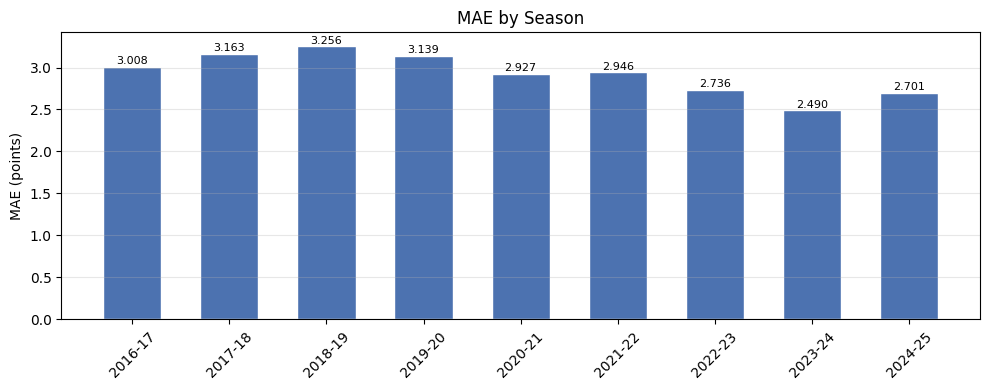

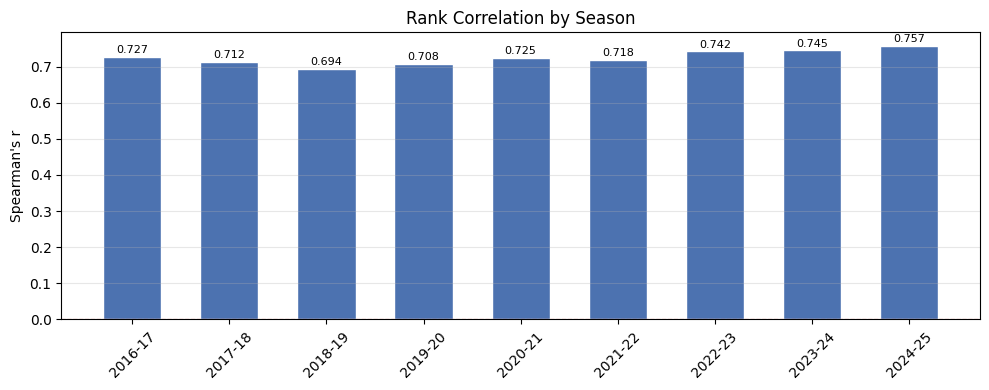

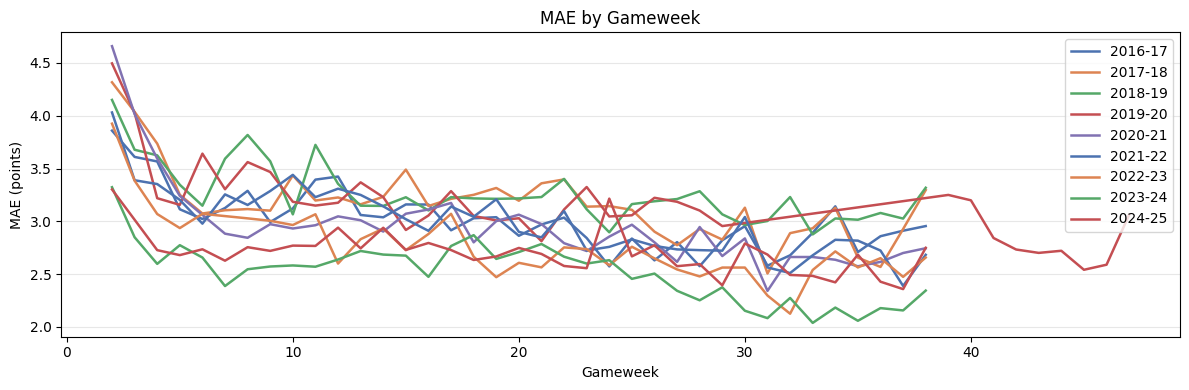

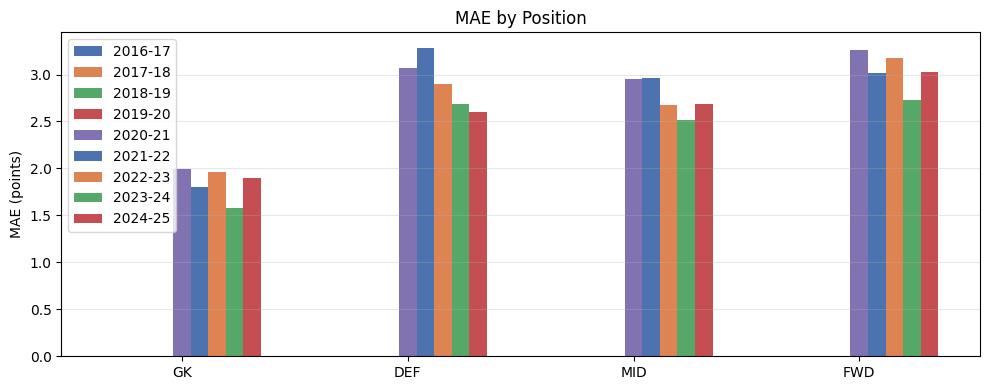

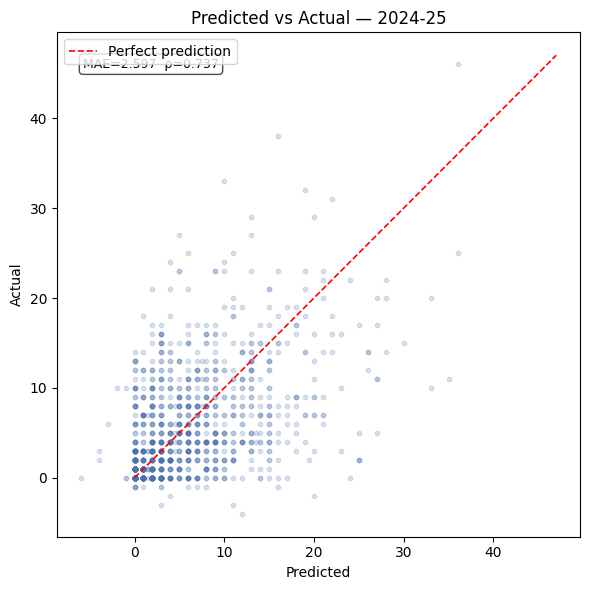

In [6]:
all_metrics = AllMetrics.from_dataframe(df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

print(all_metrics.summary().to_string(index=False))

plot_all(all_metrics, df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)